<table>
    <tr> 
    <th> 
        <table>
            <tr>                                                                                   
                 <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Valeur</th>
                 <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Nom classe</th>
             </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">0</th>
                <th  style="font-size:150%;text-align:left">basophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">1</th>
                <th  style="font-size:150%;text-align:left;">eosinophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">2</th>
                <th  style="font-size:150%;text-align:left">erythroblast</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">3</th>
                <th  style="font-size:150%;text-align:left">immature</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">4</th>
                <th  style="font-size:150%;text-align:left;">lymphocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">5</th>
                <th  style="font-size:150%;text-align:left;">monocyte</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">6</th>
                <th  style="font-size:150%;text-align:left;">neutrophil</th>
            </tr>            
            <tr>
                <th  style="font-size:150%;text-align:left">7</th>
                <th  style="font-size:150%;text-align:left">platelet</th>
            </tr>            
        </table>
    </th>
    <th>     
        <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'>BloodMNIST<br> Standardized Biomedical Images</div>        
        <img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/bloodMNIST8.png" width="512">
    </th>
    </tr>
</table>   

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://github.com/MedMNIST/MedMNIST/tree/main">Veuillez vous référer à la page Github officielle pour plus de détails.</a></div>

>> **site du projet** : https://medmnist.com/

>> **site de données** : https://zenodo.org/records/10519652 


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Initialisation du document</div></b>

In [26]:
import os
# import json
# @param ["tensorflow", "jax", "torch"]
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KERAS_BACKEND'] = 'tensorflow'  
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL']='5'

import tensorflow as tf
import keras
tf.get_logger().setLevel('ERROR')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Import libriries </div></b>

In [27]:
import numpy as np, pandas as pd, seaborn as sns, warnings, os, sys, time
from matplotlib import pyplot as plt

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
    
sns.set(font_scale=2)

print(f"""La version des librairies utilisées :

Tensorflow : {tf.__version__}\tCUDA {tf.test.is_built_with_cuda()}\tGPU {tf.test.is_built_with_gpu_support()}\tXLA {tf.test.is_built_with_xla()}
Keras      : {keras.version()}
Pandas     : {pd.__version__}
NumPy      : {np.__version__}""")

La version des librairies utilisées :

Tensorflow : 2.19.1	CUDA True	GPU True	XLA True
Keras      : 3.12.0
Pandas     : 2.3.2
NumPy      : 1.26.4


## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Importer les fichiers nécessaires à l’exécution</div></b>

In [28]:
!pip install gitpython

In [29]:
import requests, os

# Dépôt et chemin
def chargementDonnees(user="rbizoi",
                      repo="FHU_TARGET_ScientificDays_2025",
                      repertoire="outils",   # sous-dossier à récupérer
                      branch = "main"):

    url = f"https://api.github.com/repos/{user}/{repo}/contents/{repertoire}?ref={branch}"
    r = requests.get(url)
    files = r.json()

    if not (os.path.exists(repertoire) & os.path.isdir(repertoire)) :
        
        os.makedirs(repertoire, exist_ok=True)
        
        for file in files:
            if file["type"] == "file":
                download_url = file["download_url"]
                file_data = requests.get(download_url).content
                with open(os.path.join(repertoire, file["name"]), "wb") as f:
                    f.write(file_data)
        print(f"Le répertoire - {repertoire} { 'a bien' if os.path.exists(repertoire) & os.path.isdir(repertoire) else 'n’a pas'} été chargé  ")
    else:                    
         print(f"Le répertoire {repertoire} existe dejà ")
    

chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire="outils",   # sous-dossier à récupérer
                   branch = "main")

# repertoire = 'donnees/BloodMNIST'
# repertoire = 'donnees/BloodMNIST224x224-4'
# repertoire = 'donnees/BloodMNIST224x224-8'
# repertoire = 'donnees/BloodMNIST36x36-4'
repertoire = 'donnees/BloodMNIST36x36-8'
# repertoire = 'donnees/BloodObjectDetection'
# repertoire = 'donnees/BloodSegmented'

chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=repertoire,   # sous-dossier à récupérer
                   branch = "main")

chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=f'{repertoire}/apprentissage',   # sous-dossier à récupérer
                   branch = "main")
chargementDonnees( user="rbizoi",
                   repo="FHU_TARGET_ScientificDays_2025",
                   repertoire=f'{repertoire}/validation',   # sous-dossier à récupérer
                   branch = "main")

Le répertoire outils existe dejà 
Le répertoire donnees/BloodMNIST36x36-8 existe dejà 
Le répertoire donnees/BloodMNIST36x36-8/apprentissage existe dejà 
Le répertoire donnees/BloodMNIST36x36-8/validation existe dejà 


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document</div></b>

In [31]:
sys.path.append(os.path.abspath('outils/'))

In [32]:
if 'configProjet' in sys.modules.keys():  del(sys.modules['configProjet'])
if 'configModele' in sys.modules.keys():  del(sys.modules['configModele'])

In [33]:
from configProjet import palette, initParametresProjet 
from configProjet import afficheHistoriqueEntrainement, afficheProbabilites, afficheMatriceConfusion, afficheDataset, afficheDistributionsPipe

In [34]:
from configModele import modelDictionnaire, initParametresExecution, getPipelineDataset
from configModele import creationCompilationModele, creationRappelsExecution, entrainementModele
from configModele import sauvegarderModel, sauvegardeHistorique, executeApprentissageChoixClassifieurs
from configModele import modelCNNSimple, modelPersonalise, modelPersonaliseInception

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Paramétrés de l’exécution et les flux de lecture des fichiers TFRecors</div></b>

In [35]:
image_size,batch_size,epochs,dictLabels,nombreClasses,pipelineApprentissage,pipelineValidation = \
       initParametresExecution(image_size=(28, 28, 3),
                            batch_size = 32,
                            epochs=128,
                            repertoire=repertoire,
                            cycle_length=None,
                            deterministic=None,
                            repetition=8,
                            bufferAleatoire=1024)

In [36]:
print(f"""
  repertoire    = {repertoire}
  image_size    = {image_size}
  batch_size    = {batch_size}
  epochs        = {epochs}
  nombreClasses = {nombreClasses}
  dictLabels    = {dictLabels}
       """)


  repertoire    = donnees/BloodMNIST36x36-8
  image_size    = (28, 28, 3)
  batch_size    = 32
  epochs        = 128
  nombreClasses = 8
  dictLabels    = {0: 'basophil', 1: 'eosinophil', 2: 'erythroblast', 3: 'immature', 4: 'lymphocyte', 5: 'monocyte', 6: 'neutrophil', 7: 'platelet'}
       


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document</div></b>

In [37]:
sys.path.append(os.path.abspath('../outils/'))

In [38]:
if 'configProjet' in sys.modules.keys():  del(sys.modules['configProjet'])
if 'configModele' in sys.modules.keys():  del(sys.modules['configModele'])

In [39]:
from configProjet import palette, initParametresProjet 
from configProjet import afficheHistoriqueEntrainement, afficheProbabilites, afficheMatriceConfusion, afficheDataset, afficheDistributionsPipe

In [40]:
from configModele import modelDictionnaire, initParametresExecution, getPipelineDataset
from configModele import creationCompilationModele, creationRappelsExecution, entrainementModele
from configModele import sauvegarderModel, sauvegardeHistorique, executeApprentissageChoixClassifieurs
from configModele import modelCNNSimple, modelPersonalise, modelPersonaliseInception

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage données</div></b>

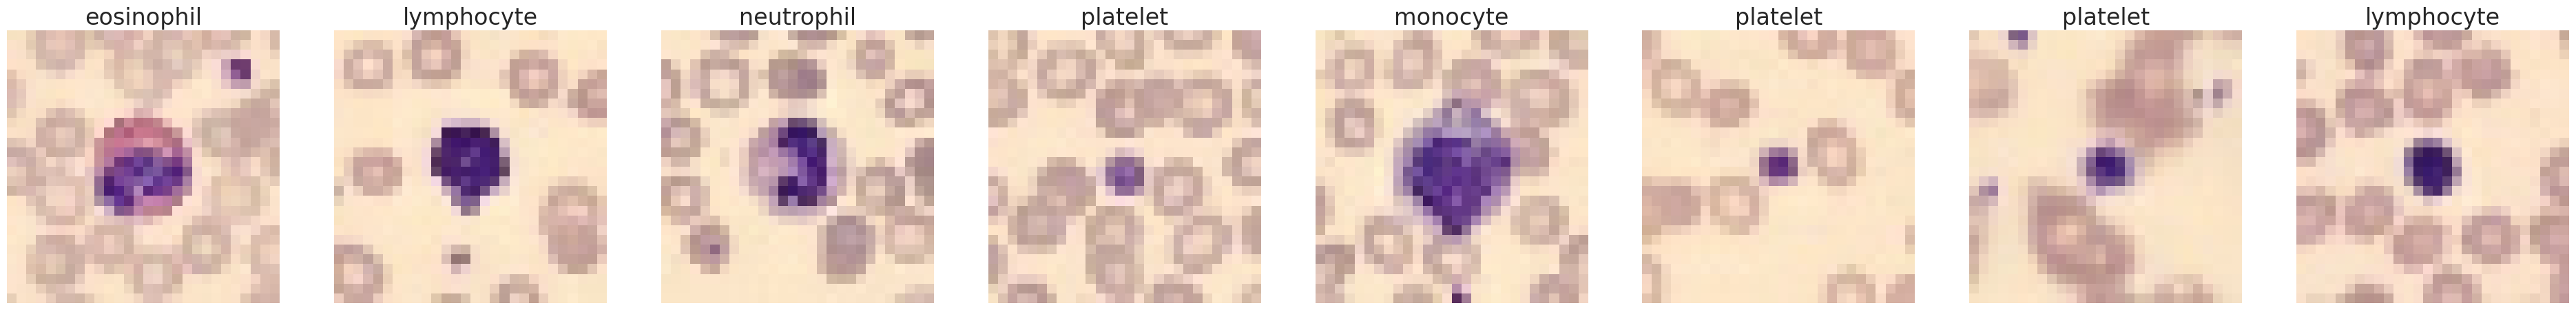

In [41]:
images, labels = next(iter(pipelineApprentissage))
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)

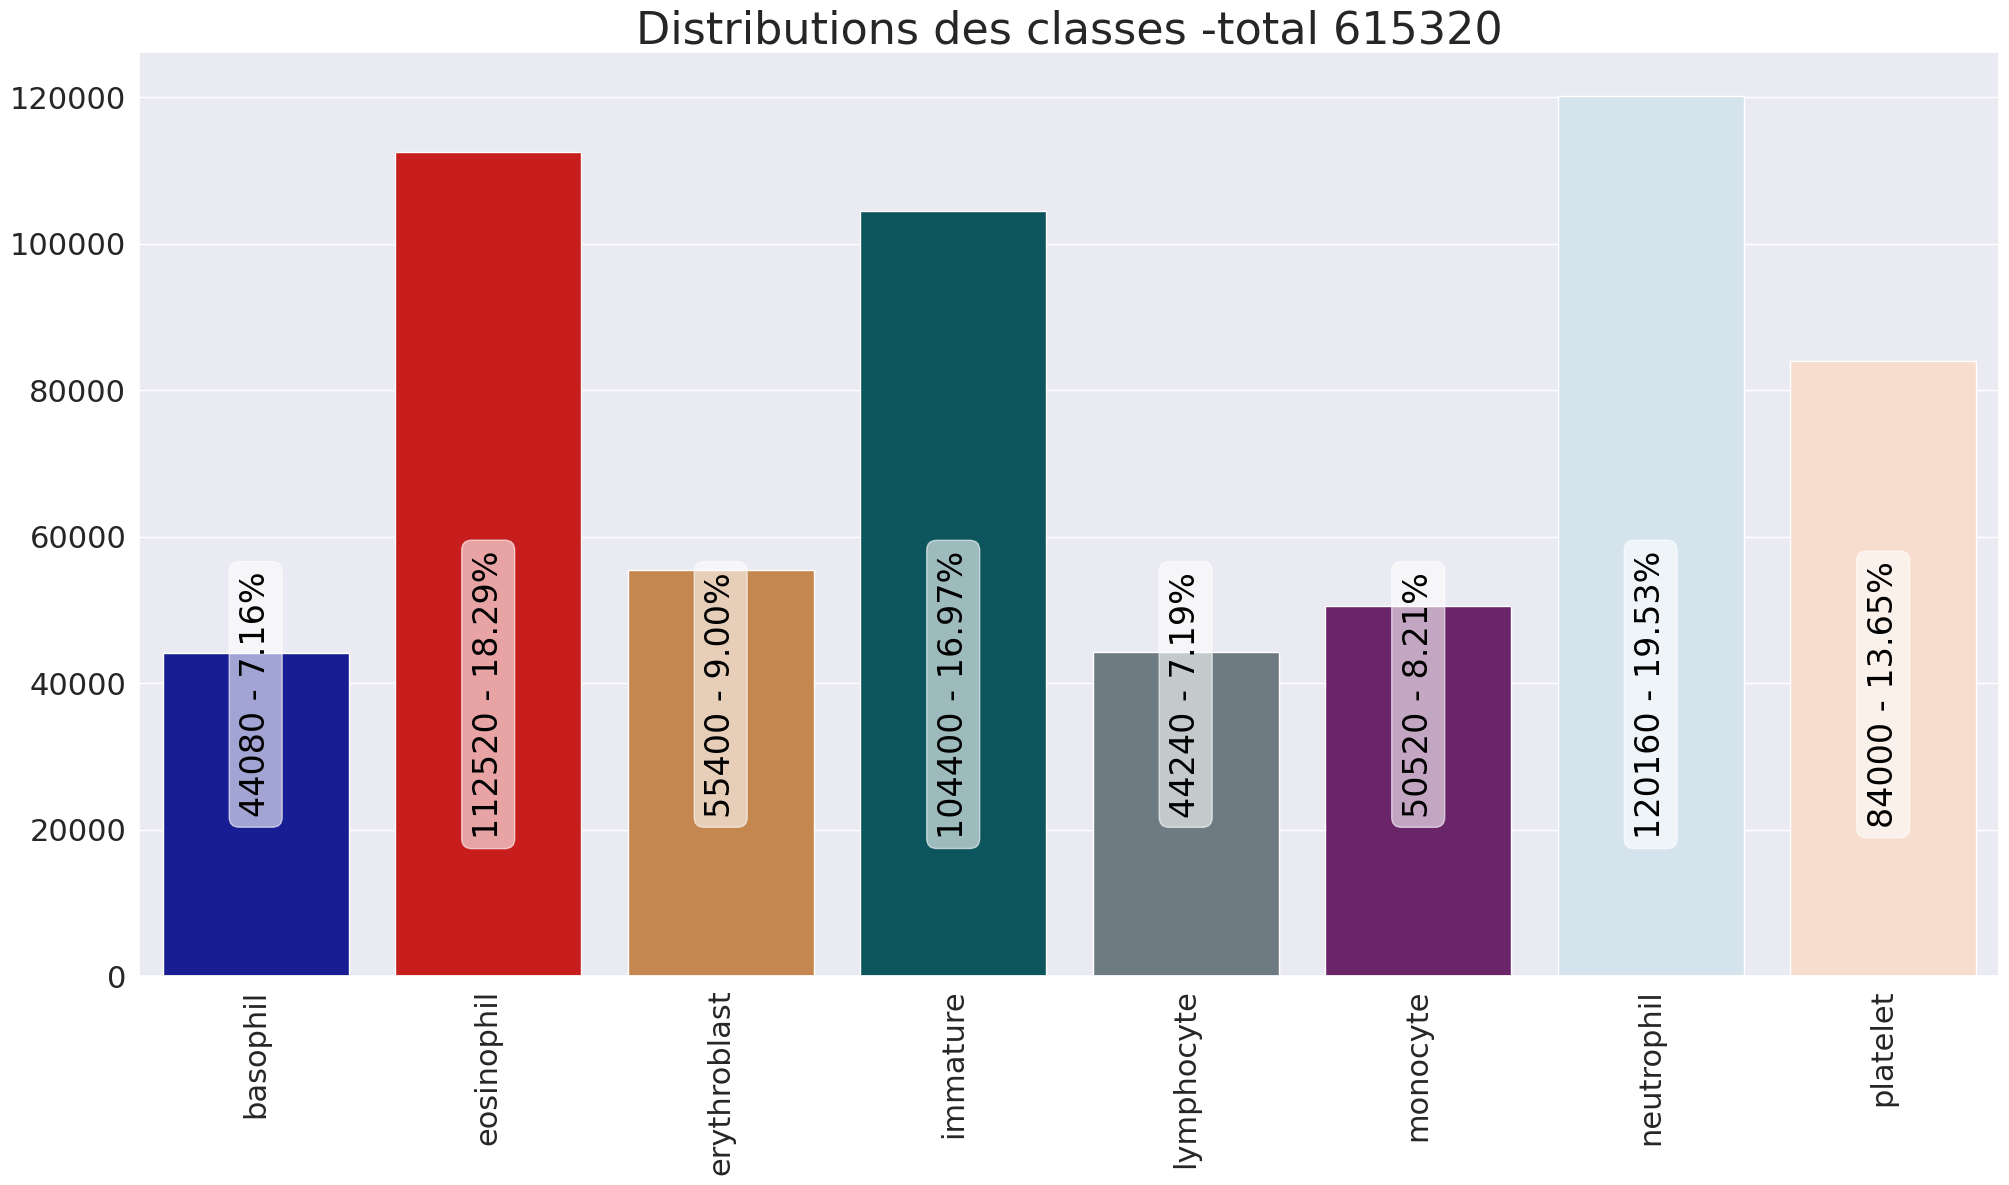

In [42]:
afficheDistributionsPipe(pipelineApprentissage, dictLabels, palette, repertoireEnregistrement=None)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Choix du modèle</div></b>

In [43]:
nomModel = 'CNN-PersonaliseMNIST-36x36-8'

In [44]:
repertoireEnregistrement,repertoireSauvegardes,repertoireModelCKP,repertoireModelSauvegarde,repertoireModelLogs = \
            initParametresProjet(nomProjet=f"3-bloodMNIST-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}",repertoireProjet='ResultatsExecutions')

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Création et compilation d'un modèle</div></b>

## <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Conception du modèle</div></b>


<table>
    <tr> 
        <th>                                                                                   
            <a href="https://arxiv.org/pdf/1512.00567"><img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/inception_3x3_1x1.png" width="512"></a>
        </th>
        <th>                                                                                   
            <a href="https://arxiv.org/pdf/1512.00567"><img src="https://raw.githubusercontent.com/rbizoi/FHU_TARGET_ScientificDays_2025/refs/heads/main/images/inception_1x3_3x1.png" width="512"></a>
        </th>
    </tr>
</table>

In [13]:
def modelPersonaliseInception(image_size, 
                              nombreClasses, 
                              listeFiltres=[128,128,256,512], 
                              dropout=0.5, 
                              activation=keras.ops.gelu, 
                              preprocessData=None):
    
    def conv2d_bn( x, filters, num_row, num_col, padding="same", strides=(1, 1), activation="relu"):
        x = keras.layers.Conv2D(filters,(num_row, num_col),strides=strides,padding=padding,use_bias=False)(x)
        x = keras.layers.BatchNormalization(scale=False)(x)
        x = keras.layers.Activation(activation)(x)
        return x        
    
    inputs = keras.Input(shape=image_size)
    
    x = preprocessData(inputs)
    
    x = keras.layers.Conv2D(listeFiltres[0], 3, strides=1, padding="same",kernel_initializer='glorot_normal',use_bias=False)(x)
    x = keras.layers.BatchNormalization(scale=False)(x)
    x = keras.layers.Activation(activation)(x)
    previous_block_activation = x  # Set aside residual
    
    for size in listeFiltres[1:]:
        branch1x1 = conv2d_bn(x, size, 1, 1, activation=activation)
        
        branch3x3 = conv2d_bn(branch1x1, size, 3, 3, activation=activation, padding="same")
        branch3x3_1 = conv2d_bn(branch3x3, size, 3, 3, activation=activation, padding="same")
        branch3x3 = keras.layers.concatenate([branch3x3, branch3x3_1])
    
        branch_pool = keras.layers.AveragePooling2D((3, 3), strides=(1, 1), padding="same")(x)
        branch_pool  = conv2d_bn(branch_pool, size//2, 1, 1, activation=activation)

        branch3x3X1 = conv2d_bn(branch1x1, size, 3, 3, activation=activation)
        branch3x3X1_1 = conv2d_bn(branch3x3X1, size, 1, 3, activation=activation)
        branch3x3X1_2 = conv2d_bn(branch3x3X1, size, 3, 1, activation=activation)
        branch3x3X1 = keras.layers.concatenate([branch3x3X1_1, branch3x3X1_2])

        branch3X1_1 = conv2d_bn(branch1x1, size, 1, 3, activation=activation)
        branch3X1_2 = conv2d_bn(branch1x1, size, 3, 1, activation=activation)
        branch3X1 = keras.layers.concatenate([branch3X1_1, branch3X1_2])

        x = keras.layers.concatenate([branch3x3, branch_pool, branch1x1, branch3x3X1, branch3X1],)
        x = keras.layers.Conv2D(size, 3, strides=2, padding="same",use_bias=False)(x)
        x = keras.layers.GaussianNoise(0.05)(x)
    
        residual = keras.layers.Conv2D(size, 1, strides=2, padding="same",use_bias=False)(previous_block_activation)
        
        x = keras.layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    
    x = keras.layers.GlobalAveragePooling2D()(x)
    
    x = keras.layers.Dropout(dropout)(x)
    outputs = keras.layers.Dense(nombreClasses, activation="softmax")(x)
    
    return keras.Model(inputs, outputs, name='modelPersonaliseInception')

In [14]:
preprocessData = tf.keras.Sequential([
            keras.layers.Rescaling(1.0 / 255),
        ])

model = modelPersonaliseInception(image_size, 
                   nombreClasses, 
                   activation=keras.ops.gelu,
                   listeFiltres = [64,  64, 128, 256],
                   preprocessData=preprocessData)

In [15]:
model.compile(
        optimizer=keras.optimizers.AdamW(1e-03), 
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
    )

In [16]:
model.summary()

Model: "modelPersonaliseInception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 28, 28, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │      1,728 │ sequential[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        192 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 28, 28,    │      4,096 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        192 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │     36,864 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 28, 28,    │          0 │ activation[0][0]  │
│ (AveragePooling2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │     12,288 │ activation_5[0][

 Total params: 9,288,744 (35.43 MB)

 Trainable params: 9,281,000 (35.40 MB)

 Non-trainable params: 7,744 (30.25 KB)

In [ ]:
# keras.utils.plot_model(model, show_shapes=True)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Rappels d’exécution (callbacks)</div></b>

In [18]:
callbacks = creationRappelsExecution(repertoireModelSauvegarde,
                                     repertoireModelCKP,
                                     repertoireModelLogs,
                                     patienceArretPrecoce=6,
                                     initial_lrate=1e-03,
                                     max_lrate=1e-03,
                                     min_lrate=1e-05,
                                     epochs_runup_lrate=0,
                                     epochs_sustain_lrate=0,
                                     drop_lrate=0.98)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Evolution du taux d'apprentissage</div></b>

In [19]:
def evolutionTauxApprentissage(epoch,
                               initial_lrate=1e-03,
                               max_lrate=1e-03,
                               min_lrate=1e-05,
                               epochs_runup_lrate=0,
                               epochs_sustain_lrate=0,
                               drop_lrate=0.98):
    # epochs_drop = epochs * 0.1
    if epoch < epochs_runup_lrate:
        lrate = (max_lrate - initial_lrate) / epochs_runup_lrate * epoch + initial_lrate
    elif epoch < epochs_runup_lrate + epochs_sustain_lrate:
        lrate = max_lrate
    else:
        lrate = (max_lrate - min_lrate) * drop_lrate**(epoch - epochs_runup_lrate - epochs_sustain_lrate) + min_lrate
    return lrate

L'évolution du taux d'apprentissage : du 0.001 à 8.61e-05


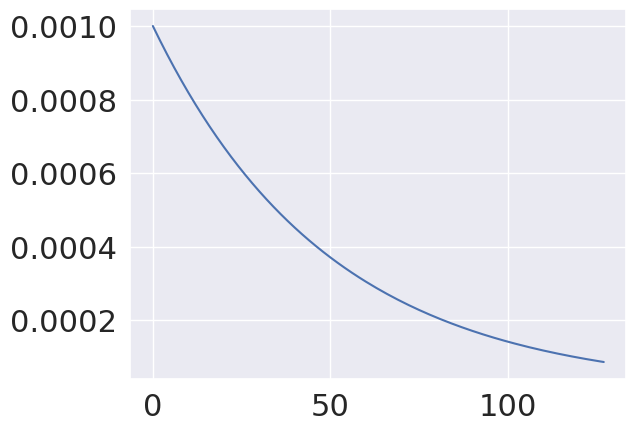

In [20]:
rng = [i for i in range(epochs)]
y = [evolutionTauxApprentissage(x) for x in rng]
plt.plot(rng, y)

print(f"L'évolution du taux d'apprentissage : du {y[0]:.3g} à {min(y):.3g}")

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Entrainement du modèle</div></b>


In [21]:
historiqueApprentissage, model = entrainementModele( model, 
                                                     pipelineApprentissage,
                                                     pipelineValidation, 
                                                     epochs, 
                                                     batch_size,
                                                     callbacks,
                                                     2, #verbose=2, 
                                                     repertoireModelSauvegarde)

Epoch 1/128


I0000 00:00:1757227171.860111   15056 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from inf to 0.58433, saving model to ../ResultatsExecutions/3-bloodMNIST-CNN-PersonaliseMNIST-36x36-8-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
2404/2404 - 48s - 20ms/step - accuracy: 0.8210 - loss: 0.7262 - val_accuracy: 0.8186 - val_loss: 0.5843 - learning_rate: 0.0010
Epoch 2/128

Epoch 2: val_loss did not improve from 0.58433
2404/2404 - 20s - 8ms/step - accuracy: 0.9080 - loss: 0.2667 - val_accuracy: 0.7109 - val_loss: 1.9427 - learning_rate: 9.8020e-04
Epoch 3/128

Epoch 3: val_loss did not improve from 0.58433
2404/2404 - 20s - 8ms/step - accuracy: 0.9247 - loss: 0.2217 - val_accuracy: 0.4839 - val_loss: 4.6329 - learning_rate: 9.6080e-04
Epoch 4/128

Epoch 4: val_loss did not improve from 0.58433
2404/2404 - 20s - 8ms/step - accuracy: 0.9348 - loss: 0.1969 - val_accuracy: 0.7490 - val_loss: 1.4394 - learning_rate: 9.4178e-04
Epoch 5/128

Epoch 5: val_loss did not improve from 0.58433
2404/2404 - 21s - 9ms/step - accuracy: 0.9405 - 

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage historique de l'apprentissage </div></b>

In [22]:
historique = sauvegardeHistorique(historiqueApprentissage,
                                  repertoireSauvegardes,
                                  nomSauvegarde=f'historique-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

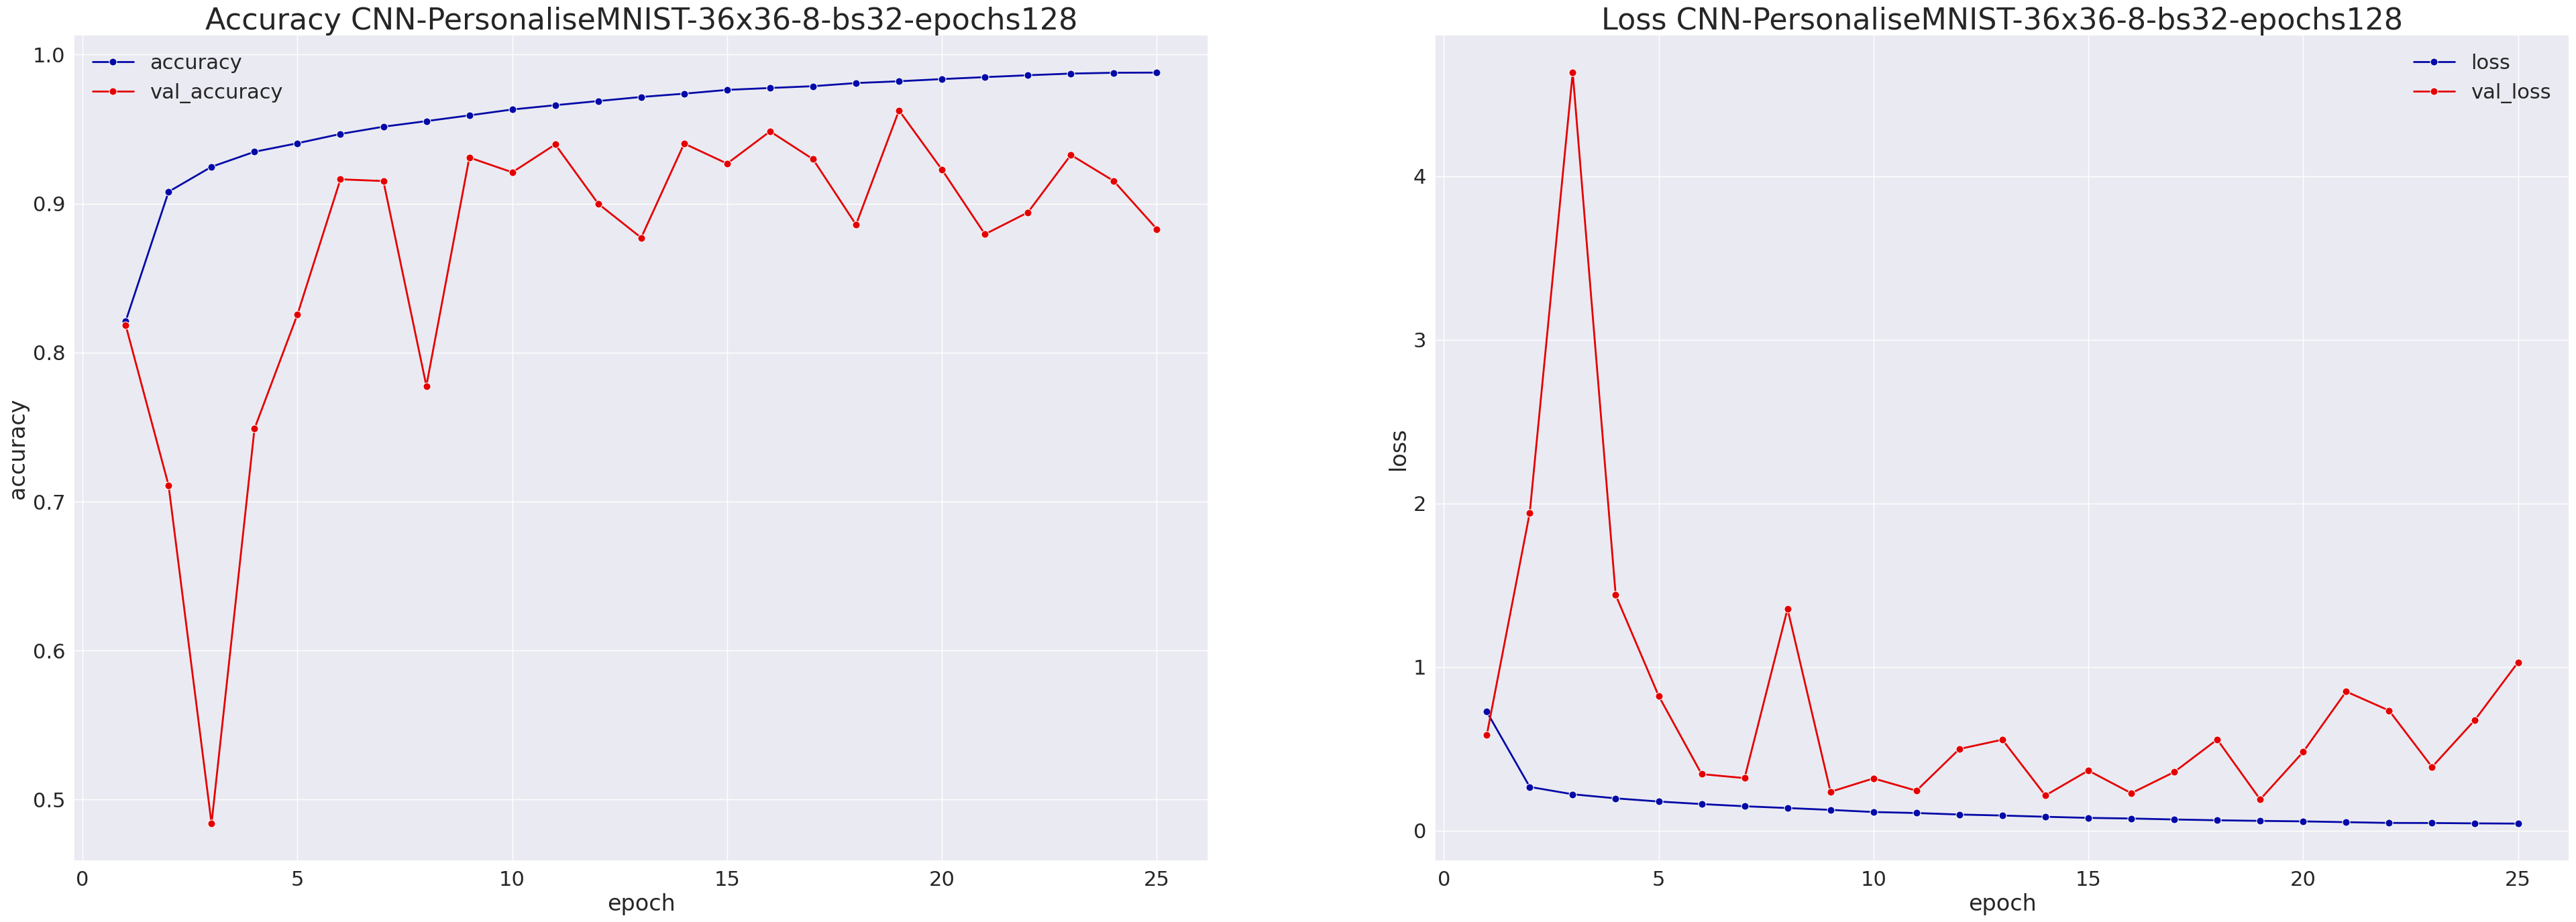

In [23]:
afficheHistoriqueEntrainement(historique, palette, f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}', repertoireEnregistrement)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Sauvegarde du modèle </div></b>

In [24]:
model.save(os.path.join(repertoireModelSauvegarde,f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.keras'))

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Inférence</div></b>

In [25]:
for i, (img,lab) in enumerate(pipelineValidation): 
    images, labels = img if i==0 else tf.concat([images,img], 0), lab if i==0 else tf.concat([labels,lab], 0)

In [26]:
probabilities = model.predict(images, verbose=0)
predictions = np.argmax(probabilities, axis=-1)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Probabilités pour les 8 premiers prédictions </div></b>

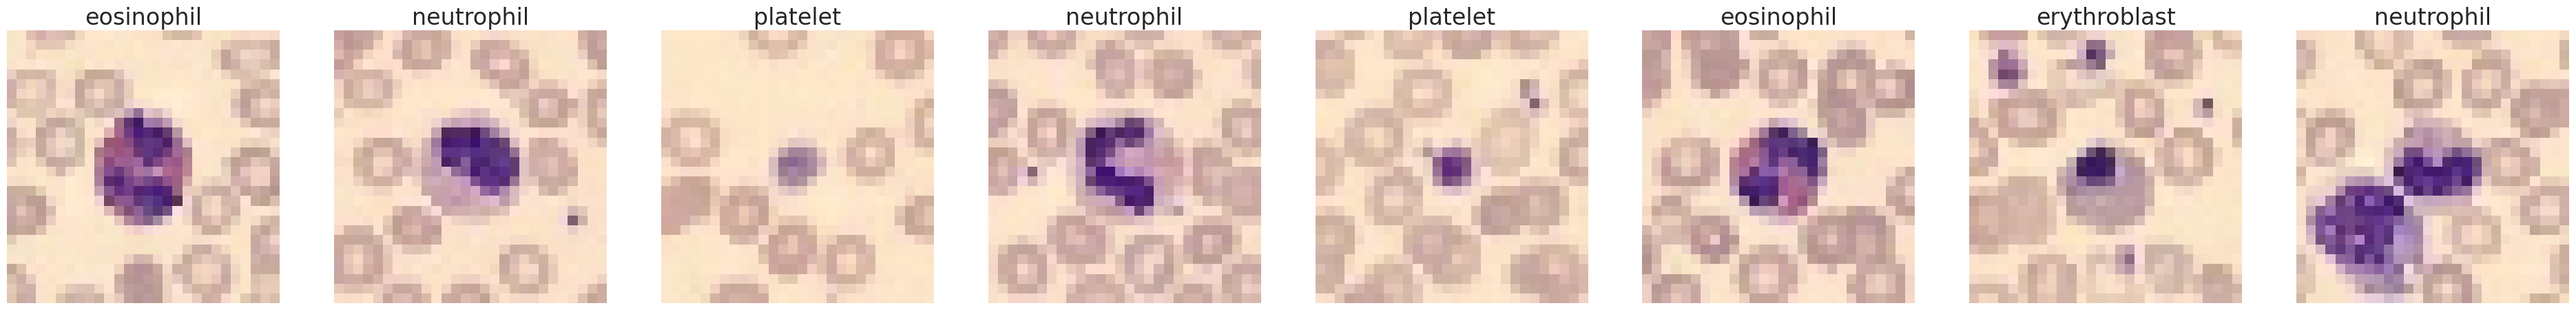

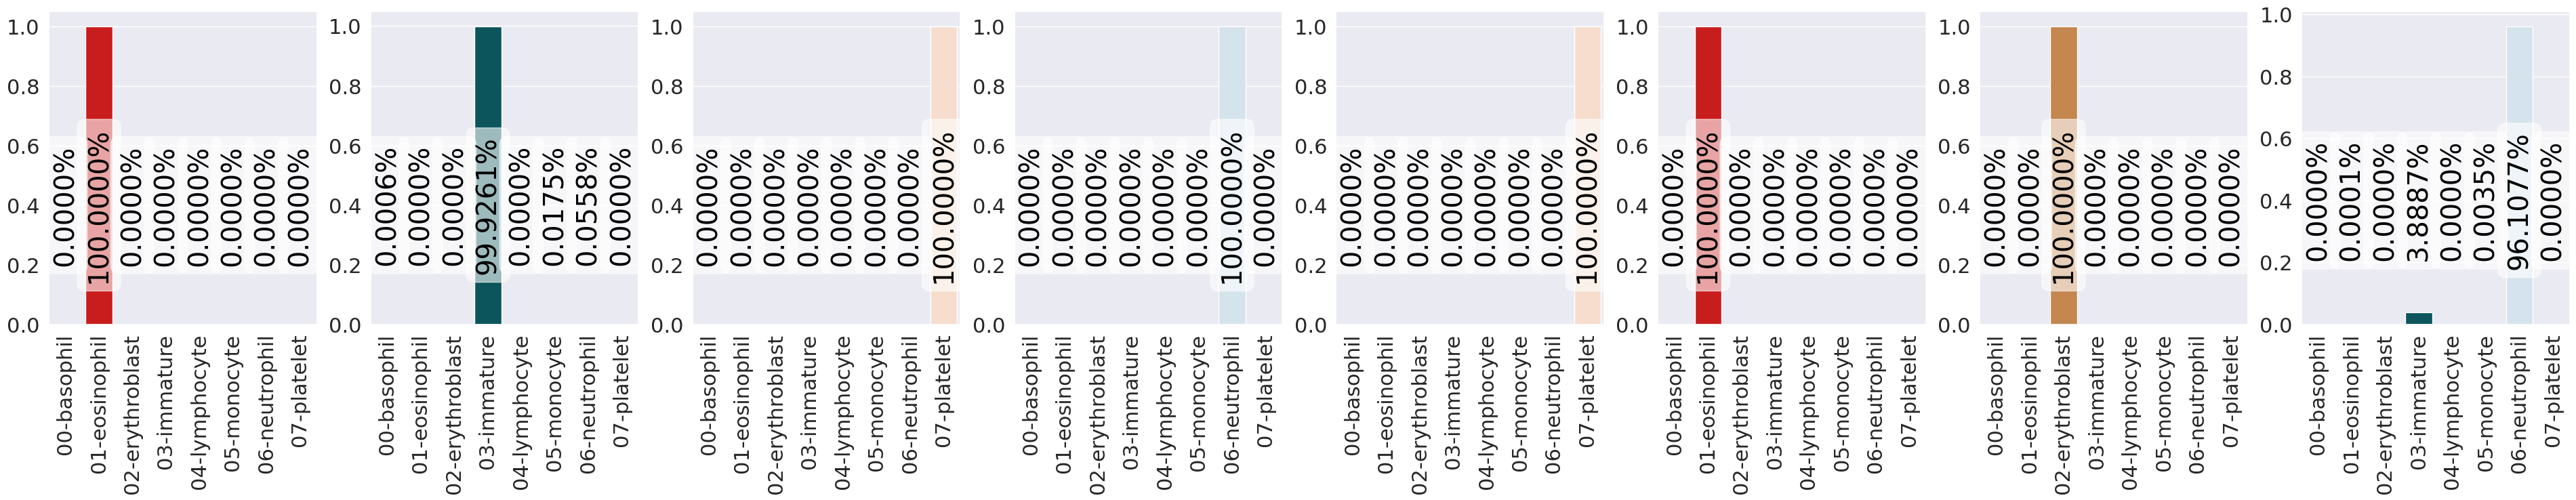

In [27]:
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)
fig, ax = plt.subplots(nrows=1, ncols=nombresImages,figsize=(6*nombresImages,6));
for i in range(nombresImages):
    afficheProbabilites(probabilities,ind=i,ax=ax[i], dictLabels=dictLabels)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Matrice de Confusion </div></b>

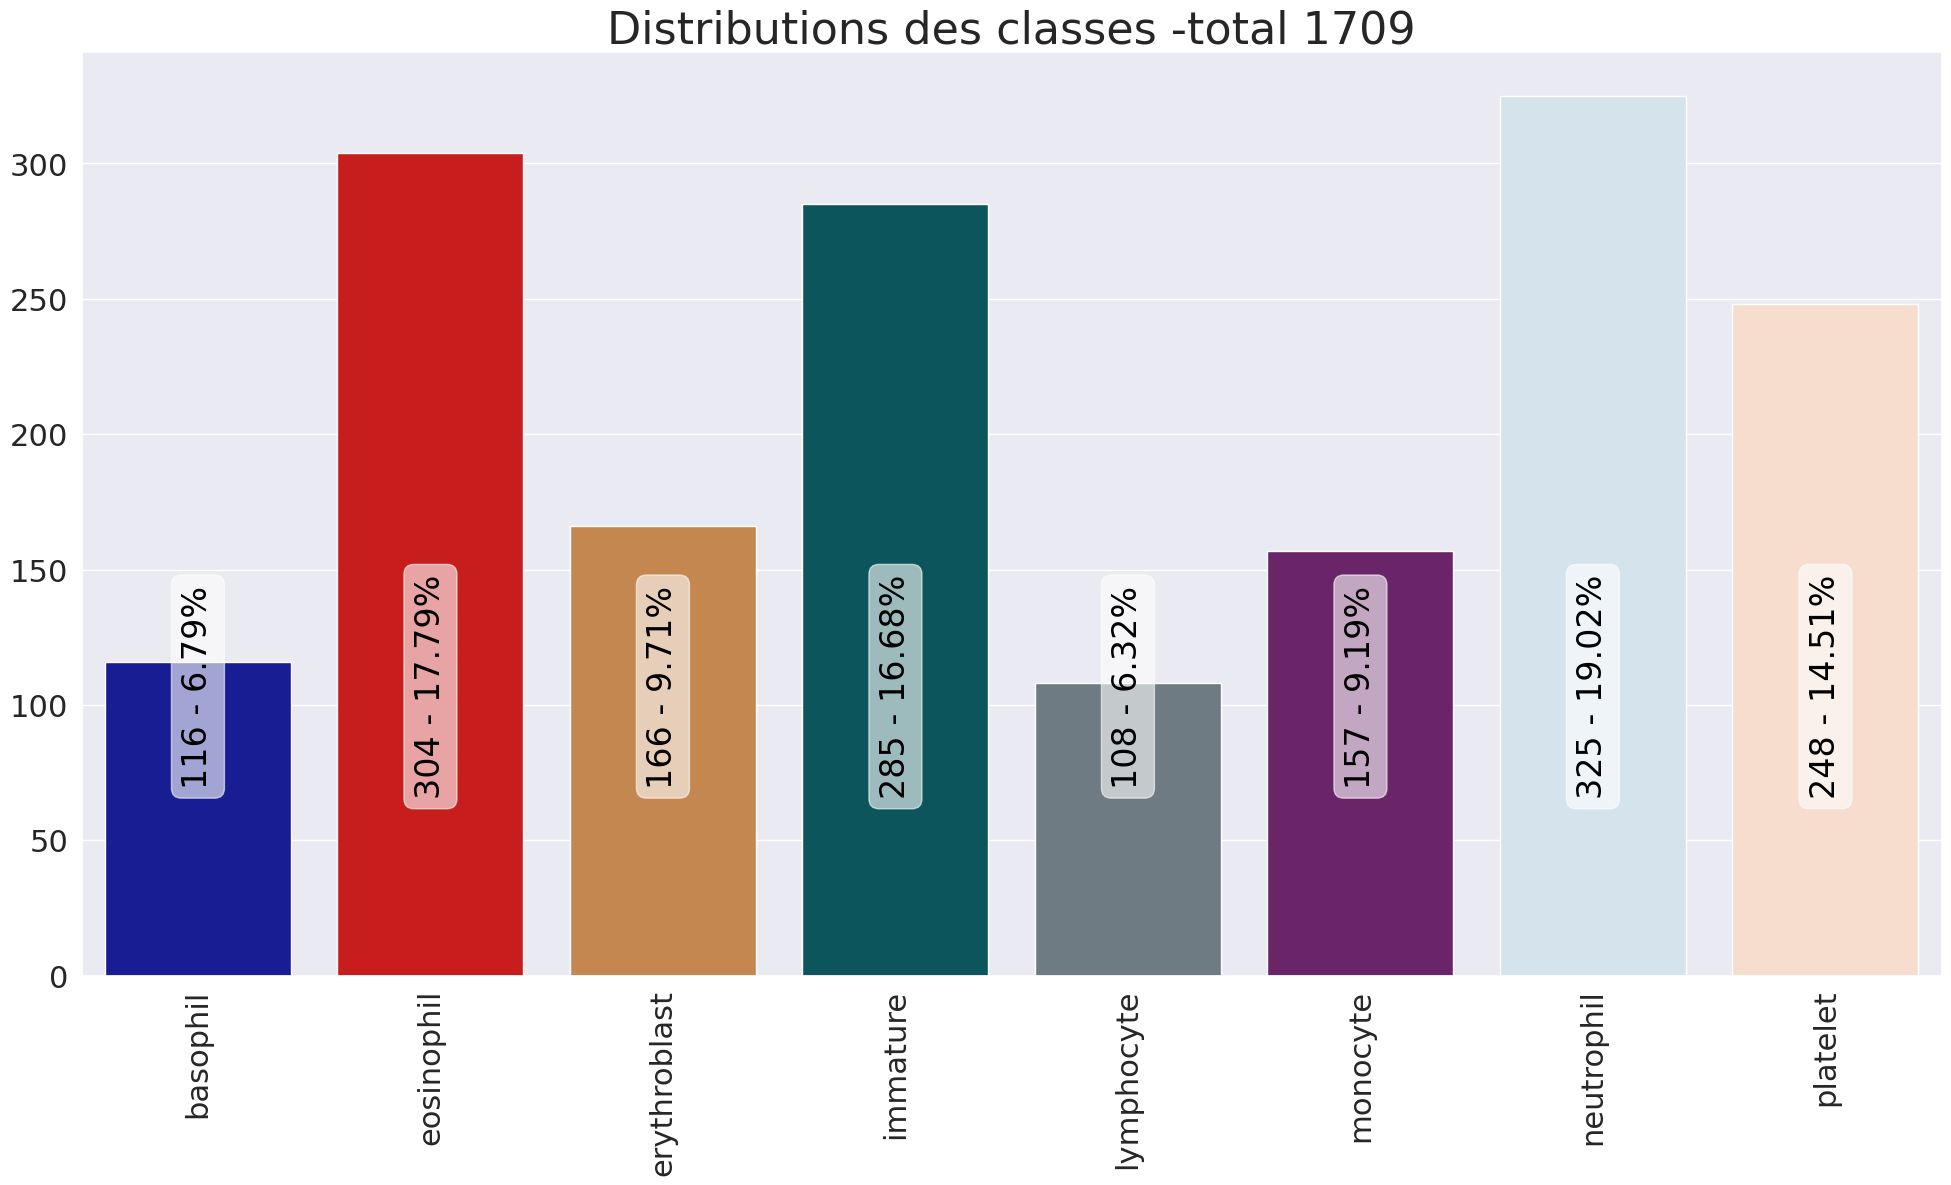

In [28]:
afficheDistributionsPipe(pipelineValidation, dictLabels, palette, repertoireEnregistrement=None)

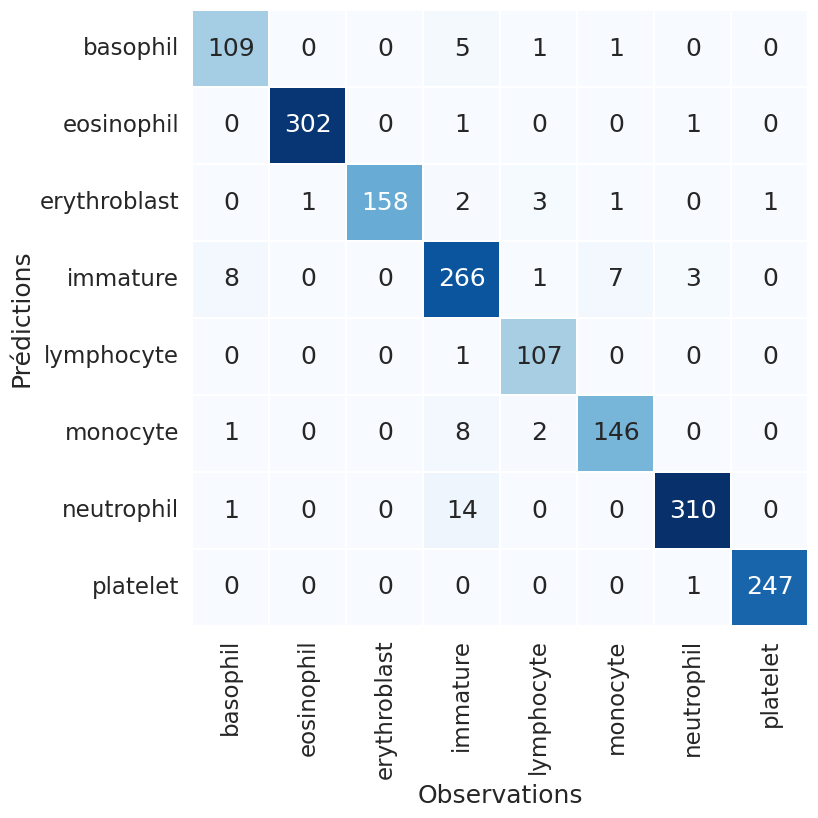

In [29]:
afficheMatriceConfusion(observations=labels,predictions=predictions,dictLabels=dictLabels, repertoireEnregistrement=repertoireEnregistrement,
                        nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Résultats de l’apprentissage</div></b>

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Area under the ROC curve : 0.9984	--	Exécution  :2.86s


,Classe,aucROC,avgPrecRec,f1,f2,f05,accuracy,precision,sensibilite,vrais_positifs,vrais_negatifs,faux_positifs,faux_negatifs,total_positifs,essai
0,global,0.998412,0.992817,0.962791,0.962593,0.963153,0.962551,0.963484,0.962551,1645,11899,64,64,1709,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128
1,basophil,0.997900,0.980545,0.927660,0.934820,0.920608,0.990053,0.915966,0.939655,109,1583,10,7,116,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128
2,eosinophil,0.999986,0.999935,0.995058,0.994075,0.996042,0.998245,0.996700,0.993421,302,1404,1,2,304,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128
3,erythroblast,0.998419,0.989887,0.975309,0.961071,0.989975,0.995319,1.000000,0.951807,158,1543,0,8,166,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128
4,immature,0.994047,0.967943,0.914089,0.925539,0.902919,0.970743,0.895623,0.933333,266,1393,31,19,285,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128
5,lymphocyte,0.999523,0.993528,0.963964,0.979853,0.948582,0.995319,0.938596,0.990741,107,1594,7,1,108,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128
6,monocyte,0.998387,0.985109,0.935897,0.932312,0.939511,0.988297,0.941935,0.929936,146,1543,9,11,157,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128
7,neutrophil,0.999075,0.996419,0.968750,0.959752,0.977918,0.988297,0.984127,0.953846,310,1379,5,15,325,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128
8,platelet,0.999961,0.999783,0.995968,0.995968,0.995968,0.998830,0.995968,0.995968,247,1460,1,1,248,CNN-PersonaliseMNIST-36x36-8-bs32-epochs128


<Figure size 1800x1800 with 0 Axes>

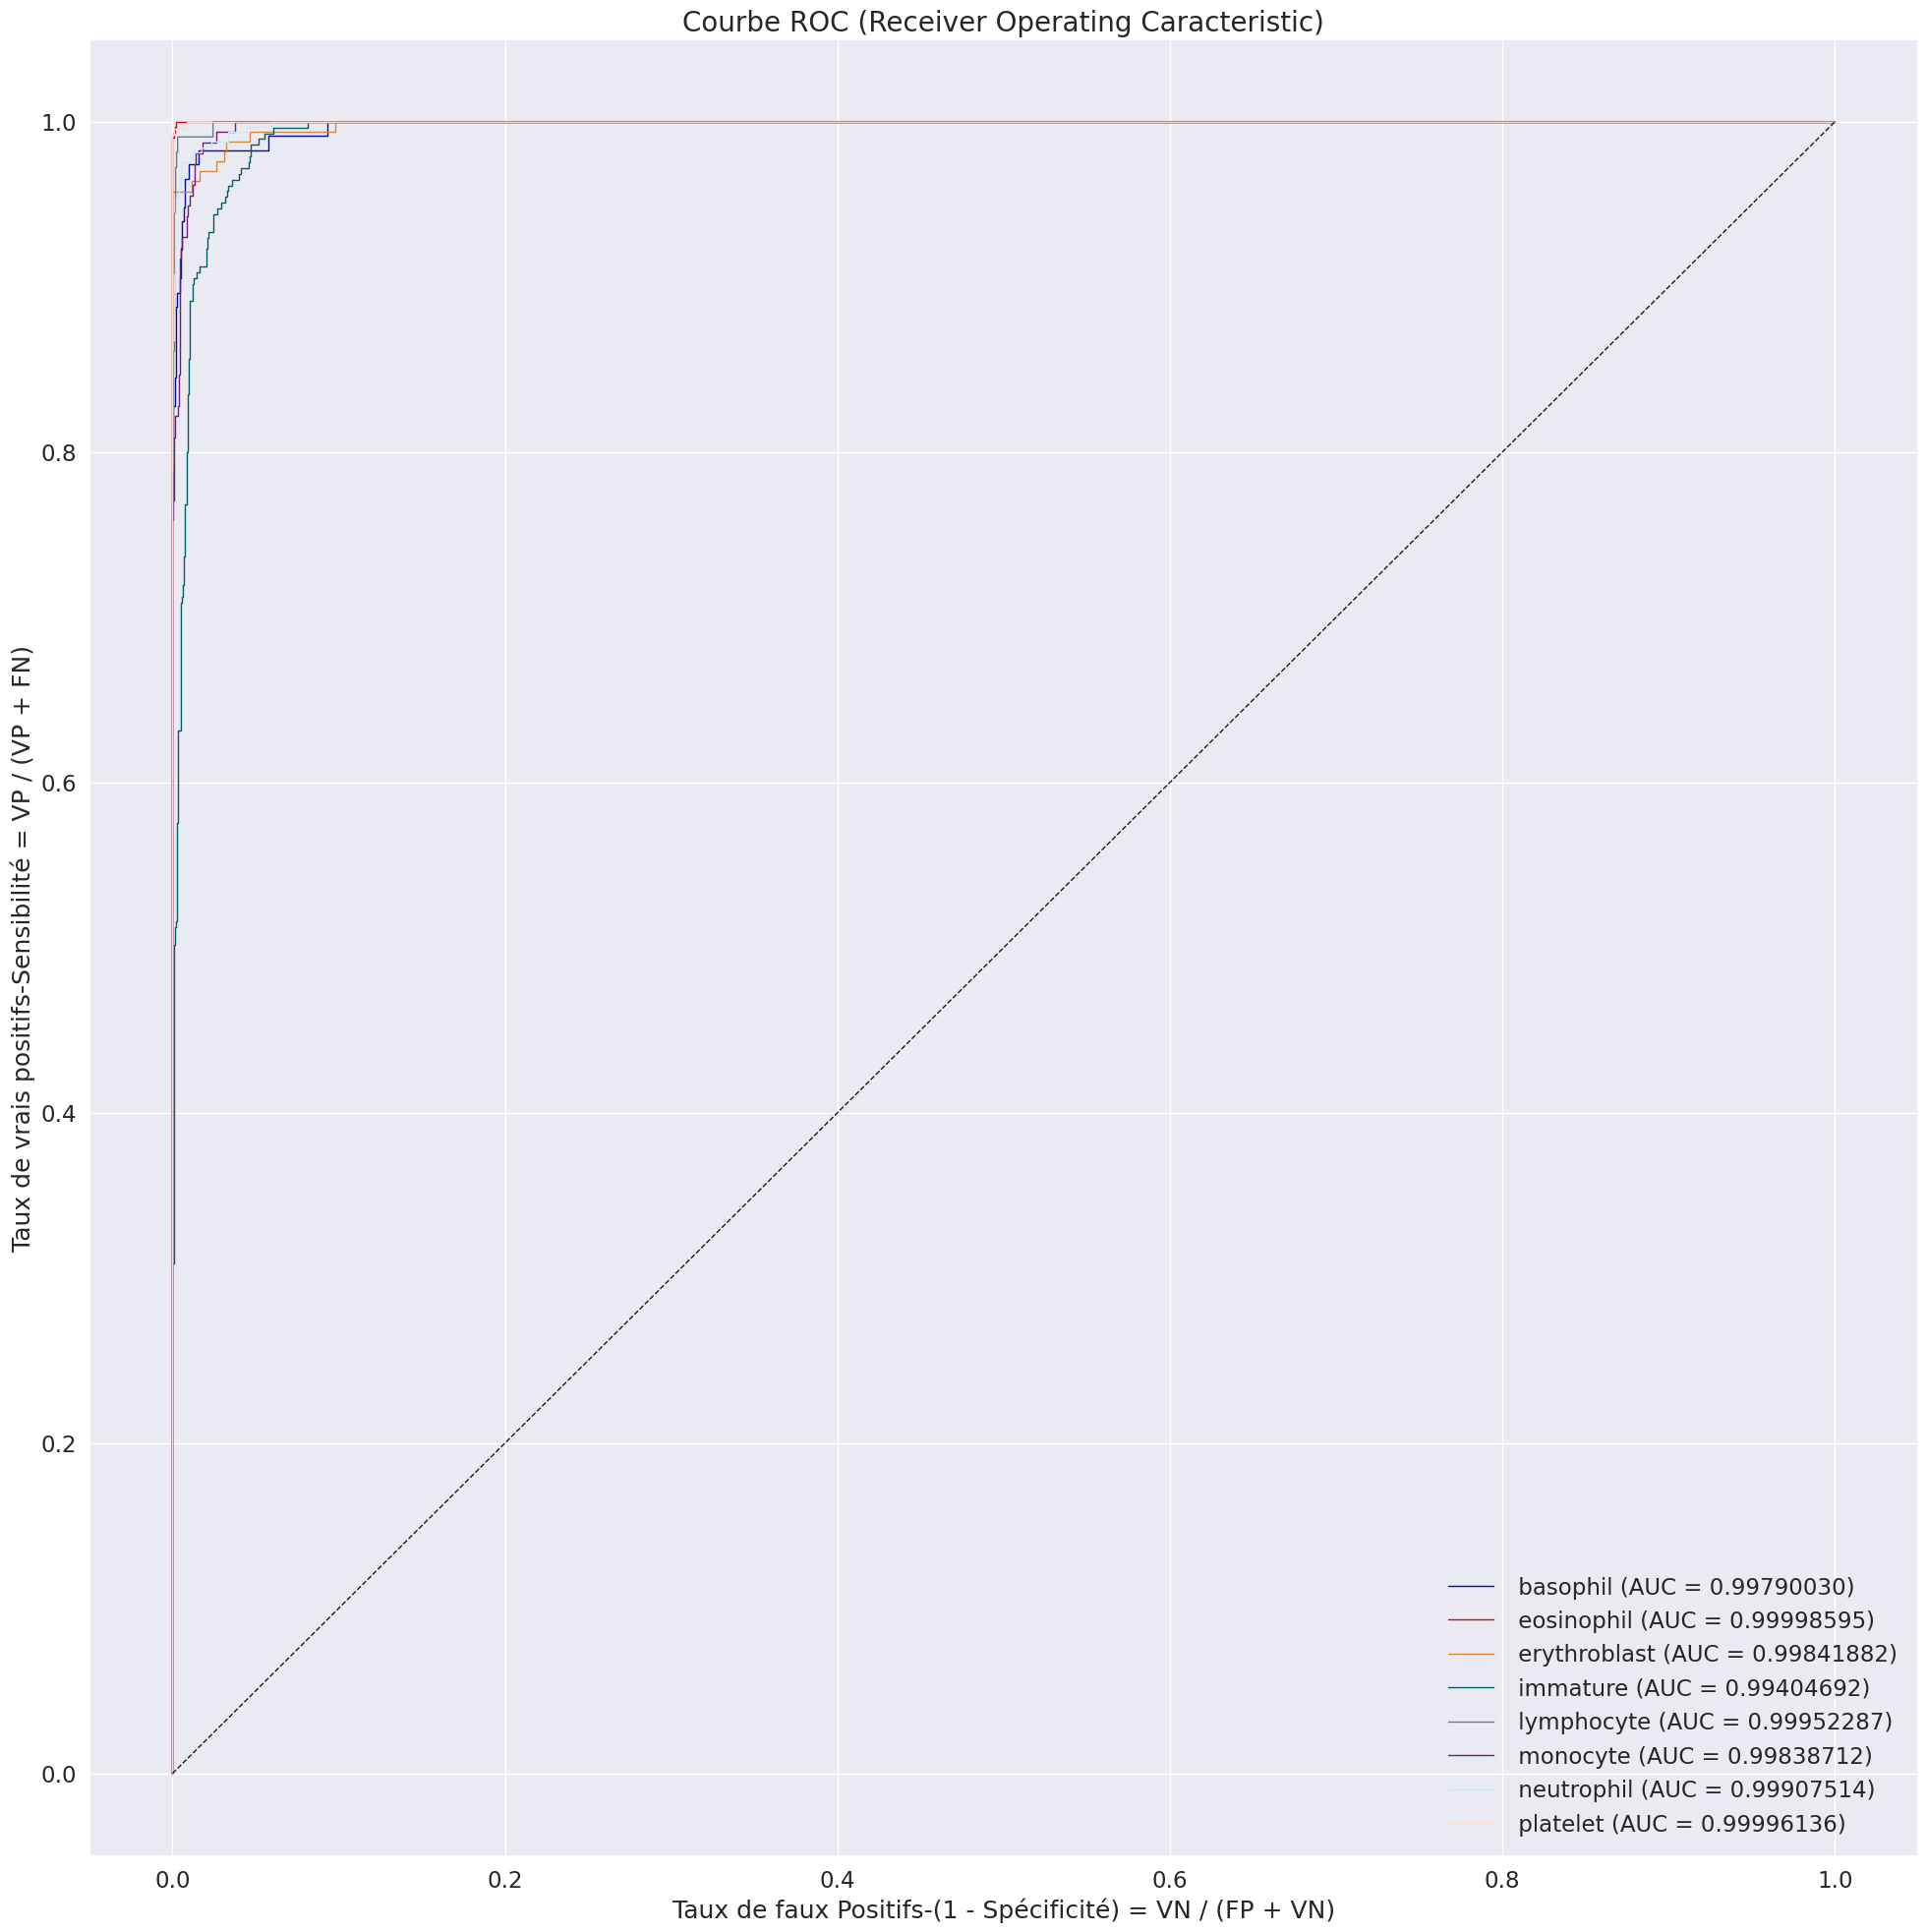

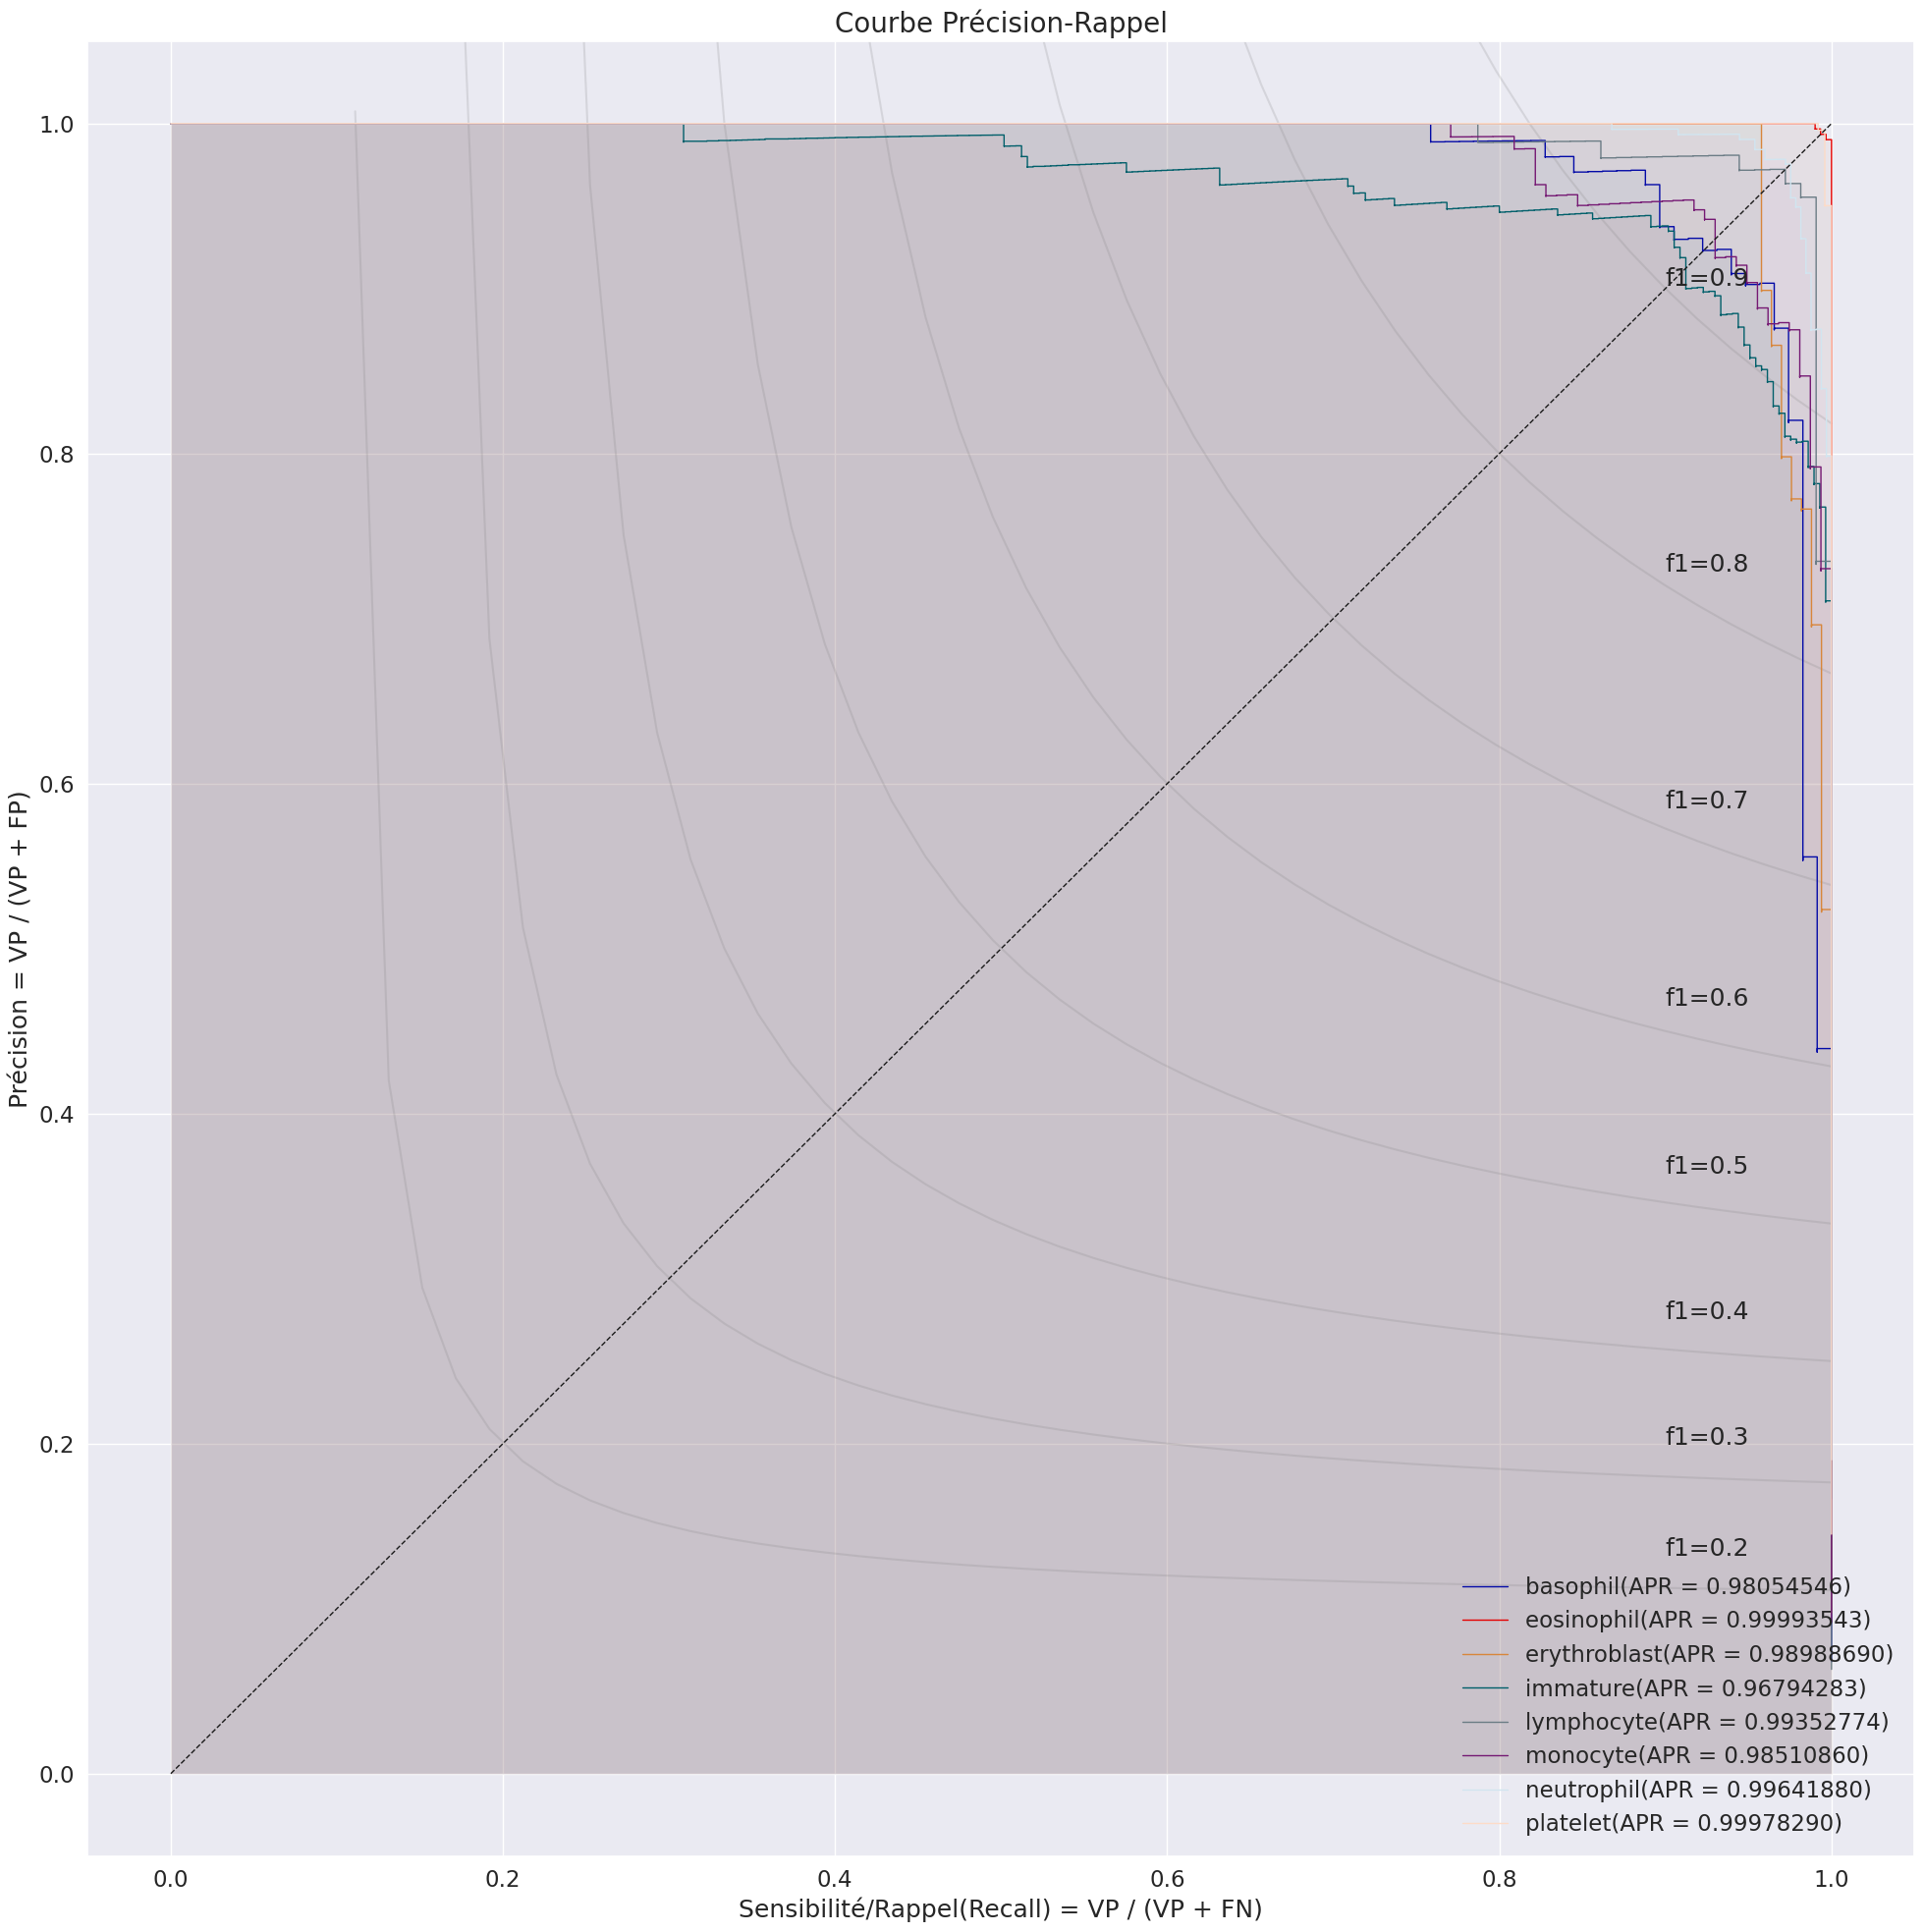

In [30]:
resultats = executeApprentissageChoixClassifieurs(
                                                  model,
                                                  X_test=images,
                                                  y_test=labels,
                                                  label_dict=dictLabels,
                                                  palette=palette, 
                                                  repertoireEnregistrement=repertoireEnregistrement,    
                                                  nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}',
                                                 );

resultats.to_parquet(os.path.join(repertoireSauvegardes,f'resultats-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.gzip'),compression='gzip', engine='pyarrow')

resultats